In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:


# Buscar cualquier CSV que contenga "brent" en el nombre
archivos_csv = list(Path.cwd().rglob("*brent*.csv"))

print("Archivos encontrados:")
for archivo in archivos_csv:
    print(archivo)

if len(archivos_csv) == 0:
    raise FileNotFoundError("No se ha encontrado ningún archivo CSV con 'brent' en el nombre.")

# Usamos el primer archivo encontrado
ruta_archivo = archivos_csv[0]

print(f"\nCargando archivo: {ruta_archivo}")

df = pd.read_csv(ruta_archivo)

df.head(10)

Archivos encontrados:
c:\Users\carme\OneDrive\Escritorio\Proyecto\databrent_oil_prices.csv

Cargando archivo: c:\Users\carme\OneDrive\Escritorio\Proyecto\databrent_oil_prices.csv


,observation_date,DCOILBRENTEU
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63
5,1987-05-27,18.60
6,1987-05-28,18.60
7,1987-05-29,18.58
8,1987-06-01,18.65
9,1987-06-02,18.68


In [15]:
# Información general del dataset
df.info()

# Resumen estadístico
df.describe()

# Ver nombres de columnas
df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 9883 entries, 0 to 10162
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         9883 non-null   datetime64[ns]
 1   precio_brent  9883 non-null   float64       
 2   año           9883 non-null   int32         
 3   mes           9883 non-null   int32         
 4   año_mes       9883 non-null   period[M]     
dtypes: datetime64[ns](1), float64(1), int32(2), period[M](1)
memory usage: 386.1 KB


Index(['fecha', 'precio_brent', 'año', 'mes', 'año_mes'], dtype='object')

In [14]:
#Estructuramos datos para poder trabajar con ellos correctamente. Renombramos y especificamos fecha y precio
df = df.rename(columns={
    "observation_date": "fecha",
    "DCOILBRENTEU": "precio_brent"
})

df["fecha"] = pd.to_datetime(df["fecha"])
df["precio_brent"] = pd.to_numeric(df["precio_brent"], errors="coerce")

df = df.dropna(subset=["precio_brent"])

df["año"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["año_mes"] = df["fecha"].dt.to_period("M")

df.head()

,fecha,precio_brent,año,mes,año_mes
0,1987-05-20,18.63,1987,5,1987-05
1,1987-05-21,18.45,1987,5,1987-05
2,1987-05-22,18.55,1987,5,1987-05
3,1987-05-25,18.60,1987,5,1987-05
4,1987-05-26,18.63,1987,5,1987-05


In [18]:
#Comprobar valores nulos

df.isnull().sum()

fecha           0
precio_brent    0
año             0
mes             0
año_mes         0
dtype: int64

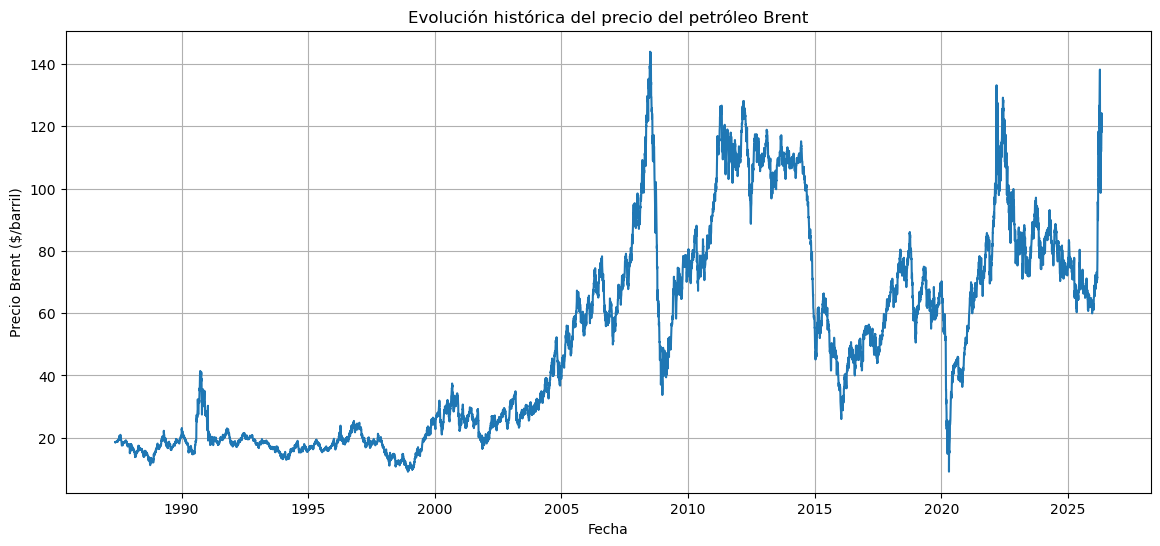

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(df["fecha"], df["precio_brent"])

plt.title("Evolución histórica del precio del petróleo Brent")
plt.xlabel("Fecha")
plt.ylabel("Precio Brent ($/barril)")
plt.grid(True)

plt.show()

In [23]:
#calculo precio anual medio
precio_anual = df.groupby("año")["precio_brent"].mean().reset_index()

precio_anual.head(10)

,año,precio_brent
0,1987,18.525813
1,1988,14.905412
2,1989,18.228228
3,1990,23.761445
4,1991,20.041128
5,1992,19.319728
6,1993,17.013413
7,1994,15.856389
8,1995,17.015850
9,1996,20.639803


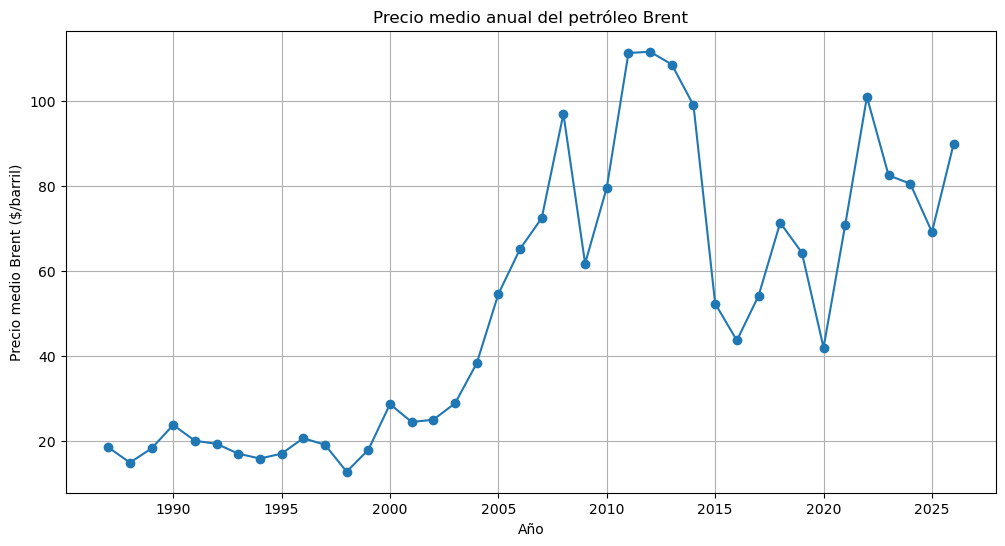

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(precio_anual["año"], precio_anual["precio_brent"], marker="o")

plt.title("Precio medio anual del petróleo Brent")
plt.xlabel("Año")
plt.ylabel("Precio medio Brent ($/barril)")
plt.grid(True)

plt.show()

In [25]:
#precios max y min por año
resumen_anual = df.groupby("año").agg(
    precio_medio=("precio_brent", "mean"),
    precio_maximo=("precio_brent", "max"),
    precio_minimo=("precio_brent", "min")
).reset_index()

resumen_anual.head()

,año,precio_medio,precio_maximo,precio_minimo
0,1987,18.525813,20.95,15.03
1,1988,14.905412,17.95,11.20
2,1989,18.228228,22.25,16.05
3,1990,23.761445,41.45,14.68
4,1991,20.041128,30.28,17.60


In [28]:
#variación porcentual del precio medio respecto al año anterior.
resumen_anual["variacion_anual_%"] = resumen_anual["precio_medio"].pct_change() * 100

resumen_anual.tail(8)

,año,precio_medio,precio_maximo,precio_minimo,variacion_anual_%
32,2019,64.300623,74.94,53.23,-9.861046
33,2020,41.957255,70.25,9.12,-34.748291
34,2021,70.855336,85.76,50.37,68.875052
35,2022,100.931310,133.18,76.02,42.447013
36,2023,82.493865,97.10,71.03,-18.267320
37,2024,80.521850,93.12,70.31,-2.390498
38,2025,69.142648,83.48,59.93,-14.131819
39,2026,89.873333,138.21,61.08,29.982486


In [32]:
eventos = {
    "COVID-19": "2020-03-01",
    "Invasión de Ucrania": "2022-02-24",
    "Tensiones Oriente Medio": "2023-10-07",
    "Crisis Mundial 2008":"2008-11-15", #dia quiebra Lehman Brothers
    "11-S":"2001-09-11"
}

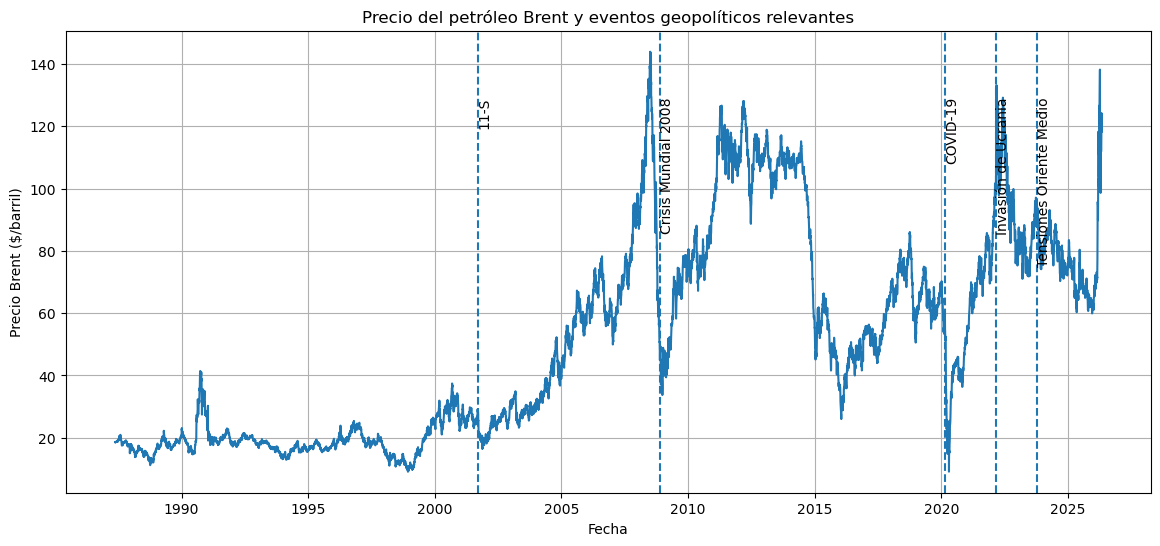

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(df["fecha"], df["precio_brent"])

for evento, fecha in eventos.items():
    fecha_evento = pd.to_datetime(fecha)
    plt.axvline(fecha_evento, linestyle="--")
    plt.text(
        fecha_evento,
        df["precio_brent"].max() * 0.9,
        evento,
        rotation=90,
        verticalalignment="top"
    )

plt.title("Precio del petróleo Brent y eventos geopolíticos relevantes")
plt.xlabel("Fecha")
plt.ylabel("Precio Brent ($/barril)")
plt.grid(True)

plt.savefig("precio_brent_eventos.png", bbox_inches="tight", dpi=300)

plt.show()

In [34]:
#años con precio medio más alto

top_10_anios_caros = resumen_anual.sort_values(
    by="precio_medio",
    ascending=False
).head(10)

top_10_anios_caros

,año,precio_medio,precio_maximo,precio_minimo,variacion_anual_%
25,2012,111.570683,128.14,88.69,0.275388
24,2011,111.264274,126.64,93.52,39.762656
26,2013,108.555000,118.90,96.84,-2.702935
35,2022,100.931310,133.18,76.02,42.447013
27,2014,98.969606,115.19,55.27,-8.829988
21,2008,96.944348,143.95,33.73,33.824952
39,2026,89.873333,138.21,61.08,29.982486
36,2023,82.493865,97.10,71.03,-18.267320
37,2024,80.521850,93.12,70.31,-2.390498
23,2010,79.609444,93.63,67.18,28.945628


In [35]:
#precios con mayores subidas anuales
top_10_subidas = resumen_anual.sort_values(
    by="variacion_anual_%",
    ascending=False
).head(10)

top_10_subidas

,año,precio_medio,precio_maximo,precio_minimo,variacion_anual_%
34,2021,70.855336,85.76,50.37,68.875052
13,2000,28.660672,37.43,21.05,60.101477
18,2005,54.574553,67.26,40.75,42.642420
35,2022,100.931310,133.18,76.02,42.447013
12,1999,17.901566,26.46,9.77,40.315269
24,2011,111.264274,126.64,93.52,39.762656
21,2008,96.944348,143.95,33.73,33.824952
17,2004,38.259693,52.28,29.02,32.612181
31,2018,71.335000,86.07,50.57,31.797242
3,1990,23.761445,41.45,14.68,30.355210


In [36]:
#Precios postcovid

df_desde_2020 = df[df["fecha"] >= "2020-01-01"]

precio_mensual_2020 = df_desde_2020.groupby("año_mes")["precio_brent"].mean().reset_index()

precio_mensual_2020["año_mes"] = precio_mensual_2020["año_mes"].astype(str)

precio_mensual_2020.head()

,año_mes,precio_brent
0,2020-01,63.645455
1,2020-02,55.657000
2,2020-03,32.011364
3,2020-04,18.378500
4,2020-05,29.378947


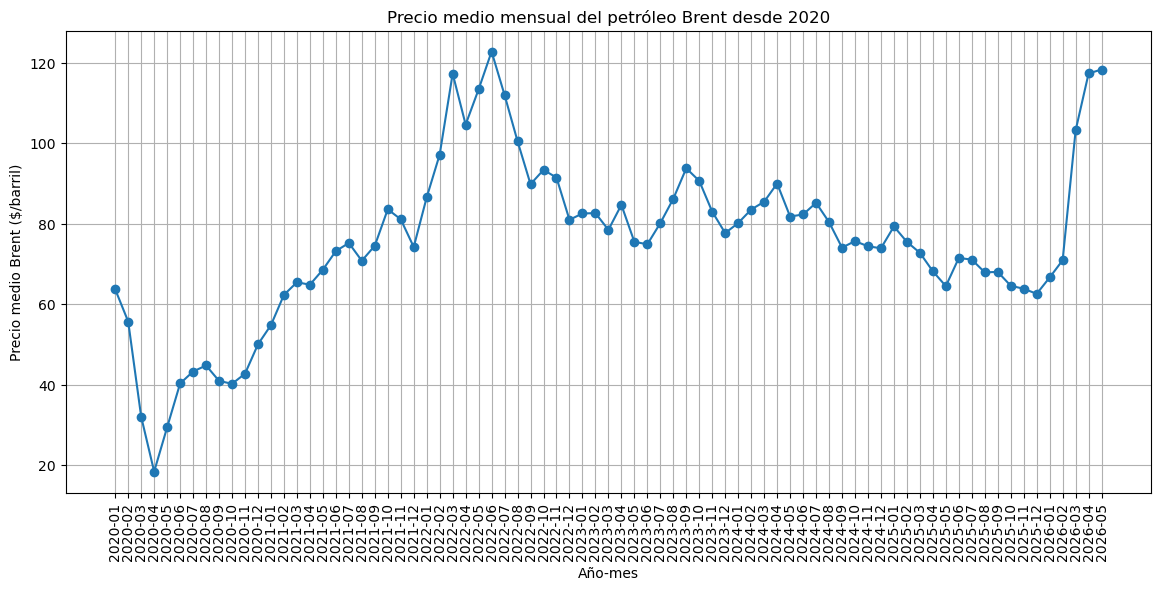

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(precio_mensual_2020["año_mes"], precio_mensual_2020["precio_brent"], marker="o")

plt.title("Precio medio mensual del petróleo Brent desde 2020")
plt.xlabel("Año-mes")
plt.ylabel("Precio medio Brent ($/barril)")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [38]:
#Explicación función: Esta función sirve para analizar cómo cambia el precio medio del Brent antes y después de un evento concreto. 
# Por ejemplo: comparar el precio medio 30 días antes y 30 días después de la invasión de Ucrania.
def analizar_evento(nombre_evento, fecha_evento, dias=30):
    fecha_evento = pd.to_datetime(fecha_evento)
    
    antes = df[
        (df["fecha"] >= fecha_evento - pd.Timedelta(days=dias)) &
        (df["fecha"] < fecha_evento)
    ]
    
    despues = df[
        (df["fecha"] > fecha_evento) &
        (df["fecha"] <= fecha_evento + pd.Timedelta(days=dias))
    ]
    
    precio_antes = antes["precio_brent"].mean()
    precio_despues = despues["precio_brent"].mean()
    variacion = ((precio_despues - precio_antes) / precio_antes) * 100
    
    resultado = {
        "evento": nombre_evento,
        "fecha": fecha_evento.date(),
        "precio_medio_antes": round(precio_antes, 2),
        "precio_medio_despues": round(precio_despues, 2),
        "variacion_%": round(variacion, 2)
    }
    
    return resultado

In [39]:
eventos = {
    "Crisis financiera global": "2008-09-15",
    "Primavera Árabe / Libia": "2011-02-15",
    "Caída precio petróleo 2014": "2014-11-27",
    "Acuerdo OPEP recorte producción": "2016-11-30",
    "COVID-19": "2020-03-01",
    "Recortes OPEP+ COVID": "2020-04-12",
    "Invasión de Ucrania": "2022-02-24",
    "Sanciones petróleo ruso UE": "2022-12-05",
    "Guerra Israel-Hamás": "2023-10-07",
    "Ataques en el Mar Rojo": "2024-01-12"
}

In [40]:
analisis_eventos = pd.DataFrame([
    analizar_evento("COVID-19", "2020-03-01", dias=30),
    analizar_evento("Invasión de Ucrania", "2022-02-24", dias=30),
    analizar_evento("Tensiones Oriente Medio", "2023-10-07", dias=30)
])

analisis_eventos

,evento,fecha,precio_medio_antes,precio_medio_despues,variacion_%
0,COVID-19,2020-03-01,55.76,32.01,-42.59
1,Invasión de Ucrania,2022-02-24,95.22,116.58,22.43
2,Tensiones Oriente Medio,2023-10-07,93.47,90.11,-3.60


In [42]:
# Exportar el DataFrame limpio con todas las modificaciones
df.to_csv("brent_limpio.csv", index=False)

In [43]:
#Tabla mes anterior y posterior de eventos destacables entre 1987 y 2026

import pandas as pd

eventos_data = [
    {
        "fecha_evento": "1987-10-19",
        "evento": "Lunes Negro",
        "categoria": "Crisis financiera",
        "descripcion": "Fuerte caída de los mercados bursátiles internacionales."
    },
    {
        "fecha_evento": "1990-08-02",
        "evento": "Invasión de Kuwait por Irak",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Inicio de la crisis del Golfo, con impacto relevante en el mercado del petróleo."
    },
    {
        "fecha_evento": "1991-01-17",
        "evento": "Guerra del Golfo",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Inicio de la operación militar internacional contra Irak."
    },
    {
        "fecha_evento": "1997-07-02",
        "evento": "Crisis financiera asiática",
        "categoria": "Crisis financiera",
        "descripcion": "Crisis económica en Asia con impacto sobre la demanda global de materias primas."
    },
    {
        "fecha_evento": "1998-12-01",
        "evento": "Caída del precio del petróleo en 1998",
        "categoria": "Mercado energético",
        "descripcion": "Periodo de precios bajos del petróleo asociado a menor demanda y exceso de oferta."
    },
    {
        "fecha_evento": "2001-09-11",
        "evento": "Atentados del 11-S",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Ataques terroristas en Estados Unidos, con fuerte impacto económico y geopolítico."
    },
    {
        "fecha_evento": "2003-03-20",
        "evento": "Invasión de Irak",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Inicio de la guerra de Irak, país relevante en la producción mundial de petróleo."
    },
    {
        "fecha_evento": "2005-08-29",
        "evento": "Huracán Katrina",
        "categoria": "Desastre natural",
        "descripcion": "Afectó infraestructuras energéticas en el Golfo de México."
    },
    {
        "fecha_evento": "2008-07-11",
        "evento": "Máximos históricos del petróleo en 2008",
        "categoria": "Mercado energético",
        "descripcion": "El precio del petróleo alcanzó niveles históricamente elevados antes de la crisis financiera."
    },
    {
        "fecha_evento": "2008-09-15",
        "evento": "Quiebra de Lehman Brothers",
        "categoria": "Crisis financiera",
        "descripcion": "Punto crítico de la crisis financiera global."
    },
    {
        "fecha_evento": "2010-04-20",
        "evento": "Derrame Deepwater Horizon",
        "categoria": "Desastre industrial",
        "descripcion": "Accidente petrolero en el Golfo de México."
    },
    {
        "fecha_evento": "2011-02-15",
        "evento": "Primavera Árabe y crisis en Libia",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Tensiones en países productores del norte de África y Oriente Medio."
    },
    {
        "fecha_evento": "2014-06-01",
        "evento": "Expansión del shale oil en EE.UU.",
        "categoria": "Mercado energético",
        "descripcion": "Aumento de la producción estadounidense, contribuyendo a cambios en la oferta global."
    },
    {
        "fecha_evento": "2014-11-27",
        "evento": "OPEP mantiene producción en 2014",
        "categoria": "Decisión OPEP",
        "descripcion": "La OPEP decide no recortar producción en un contexto de exceso de oferta."
    },
    {
        "fecha_evento": "2016-11-30",
        "evento": "Acuerdo OPEP de recorte de producción",
        "categoria": "Decisión OPEP",
        "descripcion": "Acuerdo para reducir producción y estabilizar el mercado."
    },
    {
        "fecha_evento": "2018-05-08",
        "evento": "EE.UU. se retira del acuerdo nuclear con Irán",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Aumento de tensiones con Irán y posibles efectos sobre la oferta petrolera."
    },
    {
        "fecha_evento": "2019-09-14",
        "evento": "Ataque a instalaciones de Aramco",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Ataque a infraestructuras petroleras en Arabia Saudí."
    },
    {
        "fecha_evento": "2020-03-01",
        "evento": "Impacto global del COVID-19",
        "categoria": "Crisis sanitaria",
        "descripcion": "Caída de la demanda energética por restricciones y reducción de movilidad."
    },
    {
        "fecha_evento": "2020-04-12",
        "evento": "Recortes OPEP+ durante COVID-19",
        "categoria": "Decisión OPEP",
        "descripcion": "Acuerdo de recorte de producción ante la caída de la demanda."
    },
    {
        "fecha_evento": "2021-01-01",
        "evento": "Recuperación post-COVID",
        "categoria": "Recuperación económica",
        "descripcion": "Recuperación de la demanda energética tras las restricciones más severas."
    },
    {
        "fecha_evento": "2022-02-24",
        "evento": "Invasión rusa de Ucrania",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Inicio de la invasión rusa de Ucrania, con fuerte impacto energético en Europa."
    },
    {
        "fecha_evento": "2022-12-05",
        "evento": "Embargo europeo al petróleo ruso",
        "categoria": "Sanciones",
        "descripcion": "Entrada en vigor de restricciones europeas al petróleo ruso transportado por mar."
    },
    {
        "fecha_evento": "2023-10-07",
        "evento": "Guerra Israel-Hamás",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Aumento de tensiones en Oriente Medio."
    },
    {
        "fecha_evento": "2024-01-12",
        "evento": "Ataques en el Mar Rojo",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Tensiones sobre rutas marítimas relevantes para el comercio energético."
    },
    {
        "fecha_evento": "2026-02-28",
        "evento": "Escalada bélica EE.UU.-Israel-Irán",
        "categoria": "Conflicto geopolítico",
        "descripcion": "Escalada regional con impacto sobre el Estrecho de Ormuz y el mercado energético."
    }
]



In [45]:
analisis_eventos = pd.DataFrame([
    analizar_evento("Lunes Negro", "1987-10-19", dias=30),
    analizar_evento("Invasión de Kuwait por Irak", "1990-08-02", dias=30),
    analizar_evento("Guerra del Golfo", "1991-01-17", dias=30),
    analizar_evento("Crisis financiera asiática", "1997-07-02", dias=30),
    analizar_evento("Caída del precio del petróleo en 1998", "1998-12-01", dias=30),
    analizar_evento("Atentados del 11-S", "2001-09-11", dias=30),
    analizar_evento("Invasión de Irak", "2003-03-20", dias=30),
    analizar_evento("Huracán Katrina", "2005-08-29", dias=30),
    analizar_evento("Máximos históricos del petróleo en 2008", "2008-07-11", dias=30),
    analizar_evento("Quiebra de Lehman Brothers", "2008-09-15", dias=30),
    analizar_evento("Derrame Deepwater Horizon", "2010-04-20", dias=30),
    analizar_evento("Primavera Árabe y crisis en Libia", "2011-02-15", dias=30),
    analizar_evento("Expansión del shale oil en EE.UU.", "2014-06-01", dias=30),
    analizar_evento("OPEP mantiene producción en 2014", "2014-11-27", dias=30),
    analizar_evento("Acuerdo OPEP de recorte de producción", "2016-11-30", dias=30),
    analizar_evento("EE.UU. se retira del acuerdo nuclear con Irán", "2018-05-08", dias=30),
    analizar_evento("Ataque a instalaciones de Aramco", "2019-09-14", dias=30),
    analizar_evento("Impacto global del COVID-19", "2020-03-01", dias=30),
    analizar_evento("Recortes OPEP+ durante COVID-19", "2020-04-12", dias=30),
    analizar_evento("Recuperación post-COVID", "2021-01-01", dias=30),
    analizar_evento("Invasión rusa de Ucrania", "2022-02-24", dias=30),
    analizar_evento("Embargo europeo al petróleo ruso", "2022-12-05", dias=30),
    analizar_evento("Guerra Israel-Hamás", "2023-10-07", dias=30),
    analizar_evento("Ataques en el Mar Rojo", "2024-01-12", dias=30)
])

analisis_eventos

# Exportar el resultado del análisis de eventos a CSV
analisis_eventos.to_csv(
    "analisis_eventos_brent.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo exportado correctamente: analisis_eventos_brent.csv")

Archivo exportado correctamente: analisis_eventos_brent.csv
